In [32]:
import numpy as np 
from sklearn.datasets import load_iris
from sklearn.datasets import load_wine

X, y = load_wine(return_X_y=True)
#X, y = load_iris(return_X_y=True)
from scipy.spatial.distance import pdist, squareform
dist_matrix=squareform(pdist(X,metric='Euclidean')) #D

D2=(dist_matrix)**2 

n=X.shape[0]
H=np.eye(n)-(1/n)* np.ones((n,n))
B=(-1/2)*H@D2@H

eigvals,eigvecs=np.linalg.eigh(B)

idx=np.argsort(eigvals[::-1])

eigvals=eigvals[idx]
eigvecs=eigvecs[:,idx]

k=3
v=eigvecs[:,:k]
L=np.diag(np.sqrt(eigvals[:k]))
Y=v@L


In [47]:
import matplotlib.pyplot as plt
plt.figure(figsize=(6, 5))

plt.scatter(Y[:, 0], Y[:, 1], c=y, cmap='viridis')

plt.title("MDS Visualization with Labels")
plt.xlabel("Component 1")
plt.ylabel("Component 2")
plt.colorbar()
plt.show()

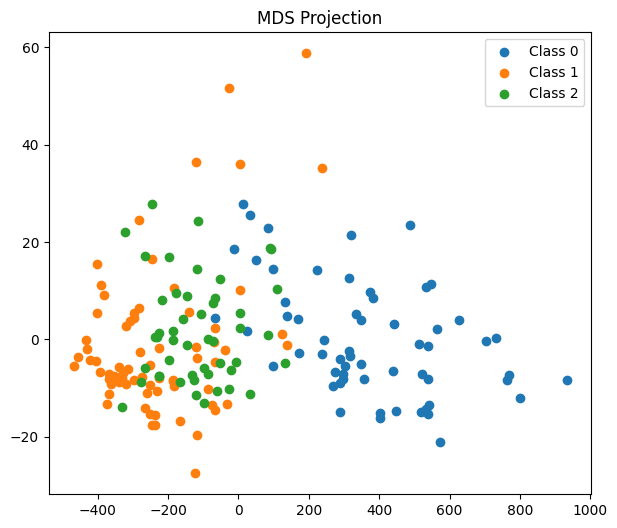

In [48]:
import numpy as np
import matplotlib.pyplot as plt

plt.figure(figsize=(7, 6))

for label in np.unique(y):
    idx = y == label
    plt.scatter(Y[idx, 0], Y[idx, 1], label=f"Class {label}")

plt.legend()
plt.title("MDS Projection")
plt.show()